In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Load — this may take 10–15 seconds on the first run
df = pd.read_csv('../data/SGJobData.csv', low_memory=False)

In [40]:
# Sanity checks
print(df.shape)          # Expect (~1048585, 20)
print(df.dtypes)
print(df.head(3))

(1048585, 22)
categories                             object
employmentTypes                        object
metadata_expiryDate                    object
metadata_isPostedOnBehalf                bool
metadata_jobPostId                     object
metadata_newPostingDate                object
metadata_originalPostingDate           object
metadata_repostCount                    int64
metadata_totalNumberJobApplication      int64
metadata_totalNumberOfView              int64
minimumYearsExperience                  int64
numberOfVacancies                       int64
occupationId                          float64
positionLevels                         object
postedCompany_name                     object
salary_maximum                          int64
salary_minimum                          int64
salary_type                            object
status_id                               int64
status_jobStatus                       object
title                                  object
average_salary      

In [41]:
df['metadata_originalPostingDate'] = pd.to_datetime(df['metadata_originalPostingDate'])
df['metadata_newPostingDate']       = pd.to_datetime(df['metadata_newPostingDate'])
df['metadata_expiryDate']           = pd.to_datetime(df['metadata_expiryDate'])

In [42]:
df

,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,...,NaN,Executive,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,...,NaN,Executive,TRUST RECRUIT PTE. LTD.,5500,4000,Monthly,0,Closed,"Software Engineer (Fab Support) (Java, CIM, Up...",4750.0
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,...,NaN,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0
3,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273991,2023-04-08,2023-04-08,0,6,113,...,NaN,Senior Executive,TRUST RECRUIT PTE. LTD.,10000,5000,Monthly,0,Closed,"Senior .NET Developer (.NET Core, MVC, MVVC, S...",7500.0
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-05-08,False,MCF-2023-0273976,2023-04-08,2023-04-08,0,3,99,...,NaN,Non-executive,EATZ CATERING SERVICES PTE. LTD.,3400,2400,Monthly,0,Closed,Sales / Admin Cordinator,2900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048580,"[{""id"":4,""category"":""Architecture / Interior D...",Part Time,2024-07-22,False,RANDOM_JOB_20251115011348190957_5,2023-10-06,2023-09-30,1,1111,2370,...,NaN,Senior Management,SAFRAN LANDING SYSTEMS SERVICES SINGAPORE PTE....,23712119,14719,Monthly,0,Re-open,Executive Secretary,11863419.0
1048581,"[{""id"":16,""category"":""General Management""},{""i...",Freelance,2024-03-18,False,RANDOM_JOB_20251115011348553903_6,2023-09-04,2023-08-12,1,131,1626,...,NaN,Executive,RECRUIT EXPRESS PTE LTD,7859259,267303,Monthly,0,Closed,Junior Project Manager (IT Infrastructure),4063281.0
1048582,"[{""id"":2,""category"":""Admin / Secretarial""},{""i...",Contract,2023-08-16,False,RANDOM_JOB_20251115011348901570_7,2023-02-24,2023-01-26,1,580,3912,...,NaN,Executive,MINDFLEX EDUCATION PTE. LTD.,13798518,260117,Monthly,0,Re-open,Social media content creator,7029317.5
1048583,"[{""id"":2,""category"":""Admin / Secretarial""},{""i...",Internship/Attachment,2024-10-11,False,RANDOM_JOB_20251115011349285489_8,2024-01-22,2024-01-03,0,465,2281,...,NaN,Professional,YUANYII AGENCY PTE. LTD.,3986060,17155,Monthly,0,Closed,Junior Sous Chef,2001607.5


In [43]:
df[df['metadata_isPostedOnBehalf']==False][['postedCompany_name']].drop_duplicates().head(53200)

,postedCompany_name
0,WORKSTONE PTE. LTD.
1,TRUST RECRUIT PTE. LTD.
2,PU TIEN SERVICES PTE. LTD.
4,EATZ CATERING SERVICES PTE. LTD.
5,BYTECENTURE CONSULTING PTE. LTD.
...,...
1048455,MARBLE SURFACE PTE. LTD.
1048458,NFTCIRCLE PTE. LTD.
1048469,7ENG PTE. LTD.
1048484,HENG LAI FURNISHING CONTRACTOR


# Basic Exploration
## Loading and initial profiling:

In [44]:
# # Shape, types, missing values at a glance
print(f"Rows: {df.shape[0]:,}  Columns: {df.shape[1]}")
print("\nNull counts:\n", df.isnull().sum().sort_values(ascending=False).head(10))
print("\nBasic stats:\n", df[['salary_minimum','salary_maximum','average_salary',
                               'minimumYearsExperience','numberOfVacancies']].describe())

Rows: 1,048,585  Columns: 22

Null counts:
 occupationId                    1048585
categories                         3988
metadata_expiryDate                3988
title                              3988
metadata_jobPostId                 3988
metadata_newPostingDate            3988
metadata_originalPostingDate       3988
status_jobStatus                   3988
salary_type                        3988
employmentTypes                    3988
dtype: int64

Basic stats:
        salary_minimum  salary_maximum  average_salary  minimumYearsExperience  \
count    1.048585e+06    1.048585e+06    1.048585e+06            1.048585e+06   
mean     3.815312e+03    5.723578e+03    4.769445e+03            2.779573e+00   
std      3.172182e+03    5.018387e+04    2.547809e+04            2.537049e+00   
min      0.000000e+00    0.000000e+00    0.000000e+00            0.000000e+00   
25%      2.500000e+03    3.300000e+03    2.900000e+03            1.000000e+00   
50%      3.000000e+03    4.500000e+03    3

## Salary cleaning with NumPy:

In [45]:
# Remove obvious outliers using the 99th percentile
p99 = np.percentile(df['average_salary'].dropna(), 99)
df_clean = df[(df['average_salary'] > 500) & (df['average_salary'] <= p99)].copy()

# Use NumPy to compute stats on the cleaned array
sal = df_clean['average_salary'].to_numpy()
print(f"Mean: {np.mean(sal):,.0f}  Median: {np.median(sal):,.0f}  Std: {np.std(sal):,.0f}")
print(f"25th pct: {np.percentile(sal, 25):,.0f}  75th pct: {np.percentile(sal, 75):,.0f}")


Mean: 4,551  Median: 3,800  Std: 2,533
25th pct: 2,900  75th pct: 5,500


## Groupby aggregation — salary by position level:

In [46]:
salary_by_level = (
    df_clean
    .groupby('positionLevels')['average_salary']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'avg_salary', 'median': 'median_salary', 'count': 'num_jobs'})
    .sort_values('median_salary', ascending=False)
)

print(salary_by_level)

                    avg_salary  median_salary  num_jobs
positionLevels                                         
Senior Management  9166.091606         8750.0     19644
Middle Management  7017.119383         6300.0     25925
Manager            6605.116159         6000.0    108347
Professional       6647.986773         6000.0    108489
Senior Executive   5586.637209         5000.0     99636
Executive          4119.707783         3750.0    252595
Junior Executive   3380.171451         3150.0    166809
Non-executive      3000.358858         2750.0    129472
Fresh/entry level  2793.007436         2600.0    115659


## Parsing the categories JSON string (one row → first category)

In [47]:
import re

def extract_first_category(cat_str):
    """Extract the first category label from the JSON-like string."""
    if pd.isna(cat_str):
        return np.nan
    match = re.search(r'"category"\s*:\s*"([^"]+)"', str(cat_str))
    return match.group(1) if match else np.nan

df_clean['primary_category'] = df_clean['categories'].apply(extract_first_category)
print(df_clean['primary_category'].value_counts().head(10))


Admin / Secretarial                 101660
Engineering                          99050
Information Technology               97682
Accounting / Auditing / Taxation     77696
Building and Construction            73640
Customer Service                     63867
F&B                                  58830
Logistics / Supply Chain             44039
Banking and Finance                  44033
Sales / Retail                       36604
Name: primary_category, dtype: int64


## Monthly posting trend:

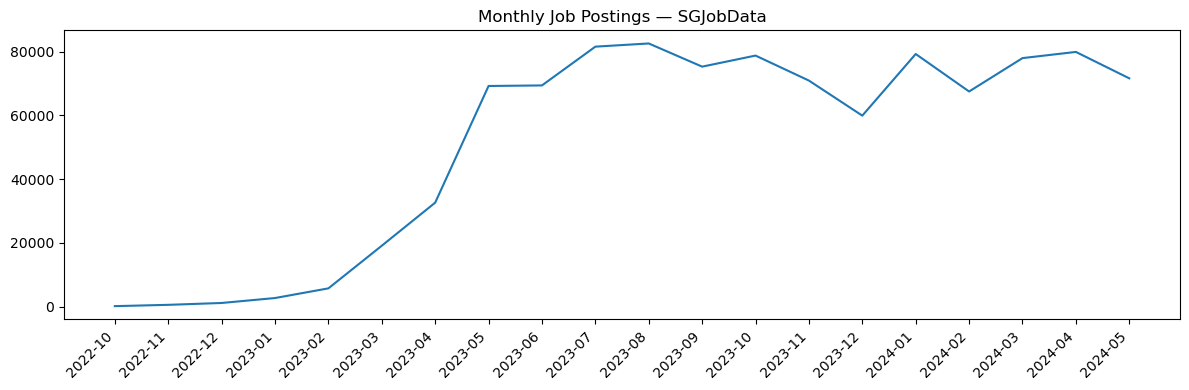

In [48]:
df_clean['year_month'] = df_clean['metadata_originalPostingDate'].dt.to_period('M')
monthly = df_clean.groupby('year_month').size().reset_index(name='postings')

plt.figure(figsize=(12, 4))
plt.plot(monthly['year_month'].astype(str), monthly['postings'])
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Job Postings — SGJobData')
plt.tight_layout()
plt.show()

## Filtering out recruitment agencies (rough heuristic):

In [49]:
agency_keywords = ['RECRUIT', 'HR ADVISORY', 'MANPOWER', 'STAFFING', 'CONSULT', 'TALENT']
pattern = '|'.join(agency_keywords)

direct_only = df_clean[
    (~df_clean['postedCompany_name'].str.upper().str.contains(pattern, na=False)) &
    (df_clean['metadata_isPostedOnBehalf'] == False)
]


## Correlation heatmap

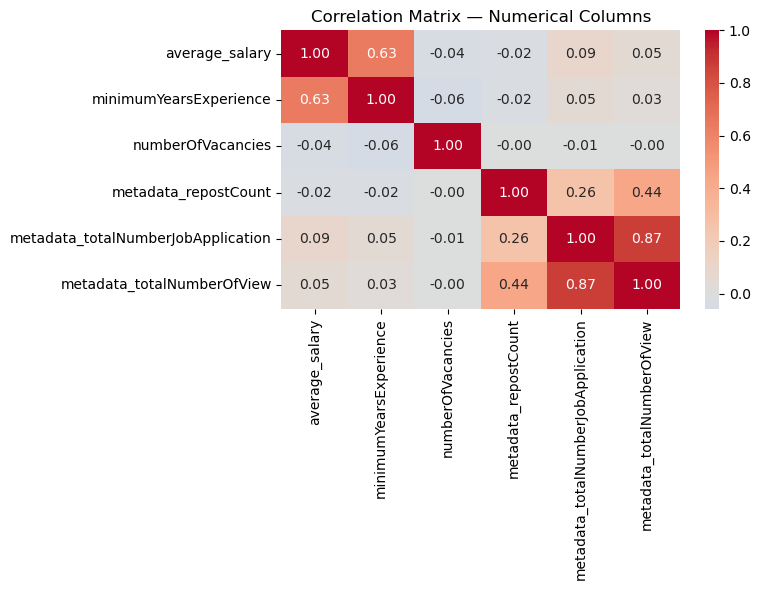

In [50]:
num_cols = ['average_salary', 'minimumYearsExperience', 'numberOfVacancies',
            'metadata_repostCount', 'metadata_totalNumberJobApplication',
            'metadata_totalNumberOfView']
corr = df_clean[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numerical Columns')
plt.tight_layout()
plt.show()


## Boxplot for outlier inspection:

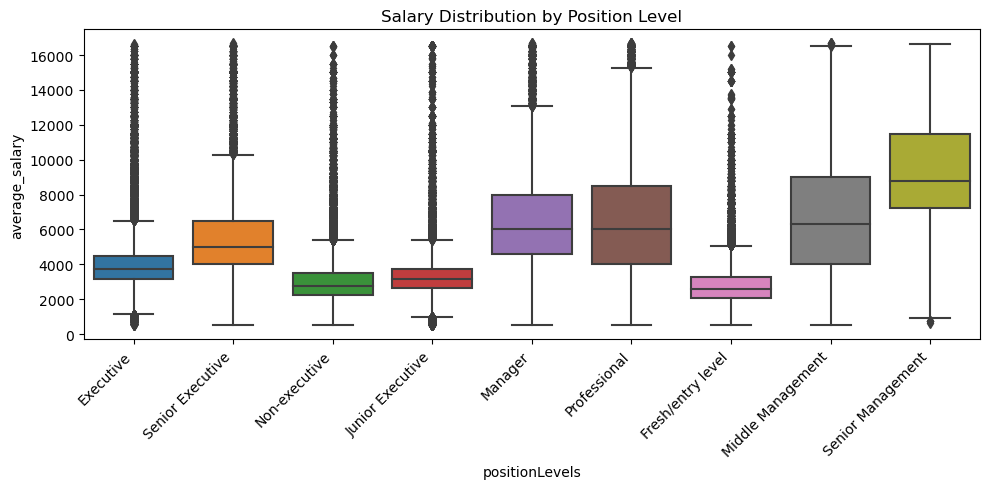

In [51]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='positionLevels', y='average_salary')
plt.xticks(rotation=45, ha='right')
plt.title('Salary Distribution by Position Level')
plt.tight_layout()
plt.show()

# Question 1 

What is the shape of the DataFrame, the date range of metadata_originalPostingDate, and how many unique job post IDs are there?

In [52]:
df_clean['metadata_originalPostingDate'].describe()

/var/folders/v0/6z8pjvr11kn3v9fr5dv27sv00000gp/T/ipykernel_48317/1252485872.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  df_clean['metadata_originalPostingDate'].describe()


count                 1026576
unique                    603
top       2023-07-14 00:00:00
freq                     3956
first     2022-10-03 00:00:00
last      2024-05-29 00:00:00
Name: metadata_originalPostingDate, dtype: object

In [53]:
df_clean['metadata_jobPostId'].nunique()

1026576

# Question 2 

What are the top 10 most common primary_category values, and what percentage of all jobs does each represent? (Use .value_counts(normalize=True))

In [54]:
df_clean['categories'][0]

'[{"id":13,"category":"Environment / Health"},{"id":25,"category":"Manufacturing"},{"id":36,"category":"Sciences / Laboratory / R&D"}]'

In [55]:
df_clean['title'][0]

'Food Technologist - Clementi | Entry Level | Up to $2,800'

In [56]:
# def parse_cat(x):
#     if pd.isna(x):
#         return []
#     else:
#         return ast.literal_eval(x)

# df_clean['categories_parsed']=df_clean['categories'].apply(parse_cat)
# df_clean['categories_parsed'][0]

In [57]:
# Assumption: the first category in the list is the most relevant tag for the relevant job posting 
df_clean['primary_category'].value_counts(normalize=True).sort_values(ascending=False).head(100)

Admin / Secretarial                  0.099028
Engineering                          0.096486
Information Technology               0.095153
Accounting / Auditing / Taxation     0.075685
Building and Construction            0.071734
Customer Service                     0.062214
F&B                                  0.057307
Logistics / Supply Chain             0.042899
Banking and Finance                  0.042893
Sales / Retail                       0.035656
Education and Training               0.033978
Healthcare / Pharmaceutical          0.031471
Others                               0.023411
Consulting                           0.022830
Marketing / Public Relations         0.022318
Human Resources                      0.022090
Advertising / Media                  0.016323
Manufacturing                        0.015827
Architecture / Interior Design       0.014234
General Work                         0.014000
General Management                   0.012933
Sciences / Laboratory / R&D       

# Question 3 

After removing salary outliers, what is the median average_salary broken down by positionLevels? Sort from highest to lowest.

# Project Questions - Agencies/companies

Group by, salary trends by agencies/companies 

In [58]:
# Remove all rows from Recruitment agencies and similar intermediaries

agency_keywords = ['RECRUIT', 'HR ADVISORY', 'MANPOWER', 'STAFFING', 'CONSULT', 'TALENT']
pattern = '|'.join(agency_keywords) # create a single string pattern for regex search

agencies_only = df_clean[
    (df_clean['postedCompany_name'].str.upper().str.contains(pattern, na=False)) & # Exclude rows where company name contains any of the agency keywords
    (df_clean['metadata_isPostedOnBehalf'] == True) # Exclude rows where the job is posted on behalf of another company (likely agencies)
]

direct_only = df_clean[
    (~df_clean['postedCompany_name'].str.upper().str.contains(pattern, na=False)) & # Exclude rows where company name contains any of the agency keywords
    (df_clean['metadata_isPostedOnBehalf'] == False) # Exclude rows where the job is posted on behalf of another company (likely agencies)
]

direct_only.head()


,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary,primary_category,year_month
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,...,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0,Environment / Health,2023-03
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,...,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0,Repair and Maintenance,2023-04
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-05-08,False,MCF-2023-0273976,2023-04-08,2023-04-08,0,3,99,...,EATZ CATERING SERVICES PTE. LTD.,3400,2400,Monthly,0,Closed,Sales / Admin Cordinator,2900.0,Admin / Secretarial,2023-04
7,"[{""id"":37,""category"":""Security and Investigati...",Permanent,2023-05-08,False,MCF-2023-0273993,2023-04-08,2023-04-08,0,9,137,...,TRITON AI PTE. LTD.,7000,6500,Monthly,0,Closed,IT Security Engineer (Maritime/ Cloud Security),6750.0,Security and Investigation,2023-04
8,"[{""id"":1,""category"":""Accounting / Auditing / T...",Permanent,2023-05-12,False,MCF-2023-0261996,2023-04-12,2023-04-04,2,5,82,...,WORKSTONE PTE. LTD.,5500,3000,Monthly,0,Closed,Assistant Sales Manager (Hunter Role)- Up to $...,4250.0,Accounting / Auditing / Taxation,2023-04


In [59]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1026576 entries, 0 to 1048574
Data columns (total 24 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   categories                          1026576 non-null  object        
 1   employmentTypes                     1026576 non-null  object        
 2   metadata_expiryDate                 1026576 non-null  datetime64[ns]
 3   metadata_isPostedOnBehalf           1026576 non-null  bool          
 4   metadata_jobPostId                  1026576 non-null  object        
 5   metadata_newPostingDate             1026576 non-null  datetime64[ns]
 6   metadata_originalPostingDate        1026576 non-null  datetime64[ns]
 7   metadata_repostCount                1026576 non-null  int64         
 8   metadata_totalNumberJobApplication  1026576 non-null  int64         
 9   metadata_totalNumberOfView          1026576 non-null  int64         

In [60]:
agencies_only[['primary_category','postedCompany_name','positionLevels']].nunique()

primary_category       41
postedCompany_name    408
positionLevels          9
dtype: int64

In [61]:
agencies_only['primary_category'].drop_duplicates()

28                             General Work
93                      Admin / Secretarial
122                                  Others
162                             Engineering
428                                     F&B
620                        Customer Service
744            Marketing / Public Relations
884                      General Management
1289              Building and Construction
1363               Logistics / Supply Chain
1530                          Manufacturing
2223                    Banking and Finance
6254                 Personal Care / Beauty
6951             Purchasing / Merchandising
8927       Accounting / Auditing / Taxation
9049                 Information Technology
9332                   Environment / Health
9333                        Wholesale Trade
12946                 Professional Services
15534           Healthcare / Pharmaceutical
15721                        Sales / Retail
19203                            Consulting
19416                       Huma

In [62]:
direct_only[['postedCompany_name','positionLevels']].nunique()

postedCompany_name    50442
positionLevels            9
dtype: int64

In [63]:
direct_only['status_jobStatus'].unique()

array(['Closed', 'Re-open', 'Open'], dtype=object)

# Idea 1: Create a filter drop down comparison between direct co vs agency for same role, same cat, same position (if available), indicate that no comparable is available if none exists

In [64]:
agencies_only.groupby(['primary_category','employmentTypes','positionLevels'])['average_salary'].mean().sort_values(ascending=False)

primary_category                employmentTypes  positionLevels   
Banking and Finance             Contract         Professional         16500.000000
Architecture / Interior Design  Contract         Senior Management    16000.000000
Legal                           Permanent        Manager              15525.000000
Information Technology          Contract         Manager              14000.000000
Advertising / Media             Permanent        Senior Management    13833.333333
                                                                          ...     
Others                          Contract         Non-executive         1200.000000
Admin / Secretarial             Part Time        Fresh/entry level     1000.000000
Others                          Part Time        Non-executive         1000.000000
Admin / Secretarial             Part Time        Non-executive          850.000000
Healthcare / Pharmaceutical     Part Time        Fresh/entry level      720.000000
Name: average_salary

In [65]:
direct_only.groupby(['primary_category','employmentTypes','positionLevels'])['average_salary'].mean().sort_values(ascending=False)

primary_category                   employmentTypes        positionLevels   
Purchasing / Merchandising         Contract               Senior Management    16000.000000
Sales / Retail                     Temporary              Professional         15900.000000
Hospitality                        Contract               Middle Management    15750.000000
General Management                 Part Time              Middle Management    15000.000000
Real Estate / Property Management  Temporary              Senior Management    15000.000000
                                                                                   ...     
Sales / Retail                     Temporary              Senior Executive       750.000000
Professional Services              Internship/Attachment  Non-executive          700.000000
Education and Training             Internship/Attachment  Executive              650.000000
Events / Promotions                Freelance              Fresh/entry level      585.333333
Gene

# Idea 2: Chart a line trend for role, cat, employment type for a period 